In [2]:
import pandas as pd

# Cargar los datos (usamos try-except por si está en la raíz o dentro de 03_eda)
try:
    df = pd.read_csv('Default of credit card clients.csv', sep=';')
except FileNotFoundError:
    df = pd.read_csv('../Default of credit card clients.csv', sep=';')

# Mostrar las dimensiones y los primeros 5 registros
print(f"Total de registros: {df.shape[0]}")
print(f"Total de variables: {df.shape[1]}")
display(df.head())

Total de registros: 33377
Total de variables: 30


,bronze_record_id,source_type,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,record_origin,source_parent_id,raw_quality_flags
0,1,uci_public,1,20000.0,2,2,1,24.0,2,2,...,0.0,689.0,0.0,0.0,0.0,0.0,1,public_original,1,NaN
1,2,uci_public,2,120000.0,2,2,2,26.0,-1,2,...,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,public_original,2,NaN
2,3,uci_public,3,90000.0,2,2,2,34.0,0,0,...,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,public_original,3,NaN
3,4,uci_public,4,50000.0,2,2,1,37.0,0,0,...,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,public_original,4,NaN
4,5,uci_public,5,50000.0,1,2,1,57.0,-1,0,...,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,public_original,5,NaN


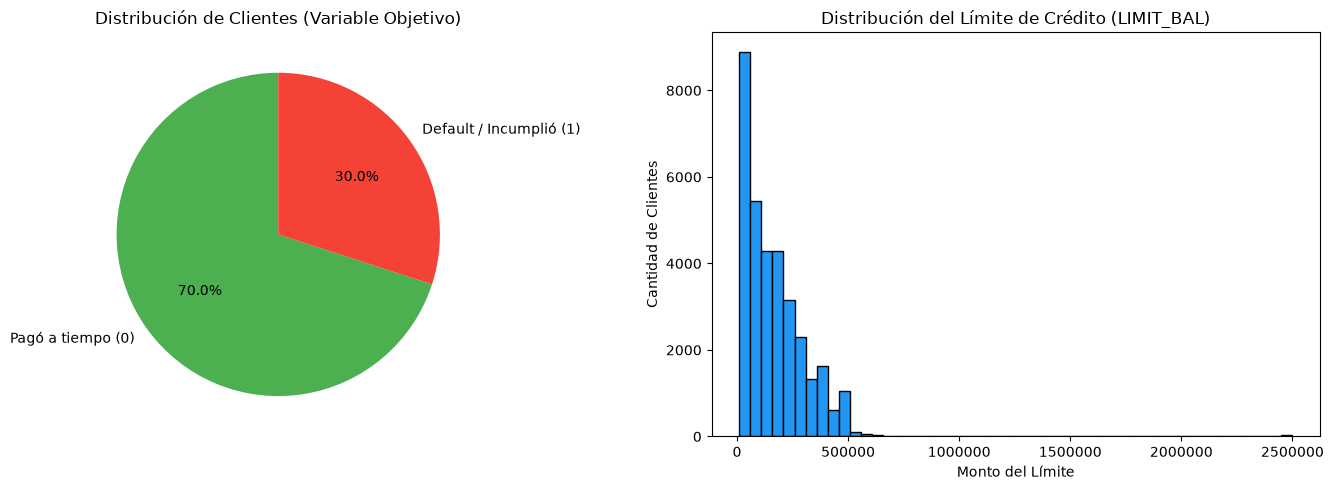

In [3]:
import matplotlib.pyplot as plt

# Crear un lienzo para 2 gráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Comprobar el balance 70/30 de la variable objetivo
plt.subplot(1, 2, 1)
conteo = df['default payment next month'].value_counts()
plt.pie(conteo, labels=['Pagó a tiempo (0)', 'Default / Incumplió (1)'], 
        autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
plt.title('Distribución de Clientes (Variable Objetivo)')

# Gráfico 2: Ver cómo se distribuye el límite de crédito de los clientes
plt.subplot(1, 2, 2)
plt.hist(df['LIMIT_BAL'], bins=50, color='#2196F3', edgecolor='black')
plt.title('Distribución del Límite de Crédito (LIMIT_BAL)')
plt.xlabel('Monto del Límite')
plt.ylabel('Cantidad de Clientes')
plt.ticklabel_format(style='plain', axis='x') # Para evitar notación científica

plt.tight_layout()
plt.show()

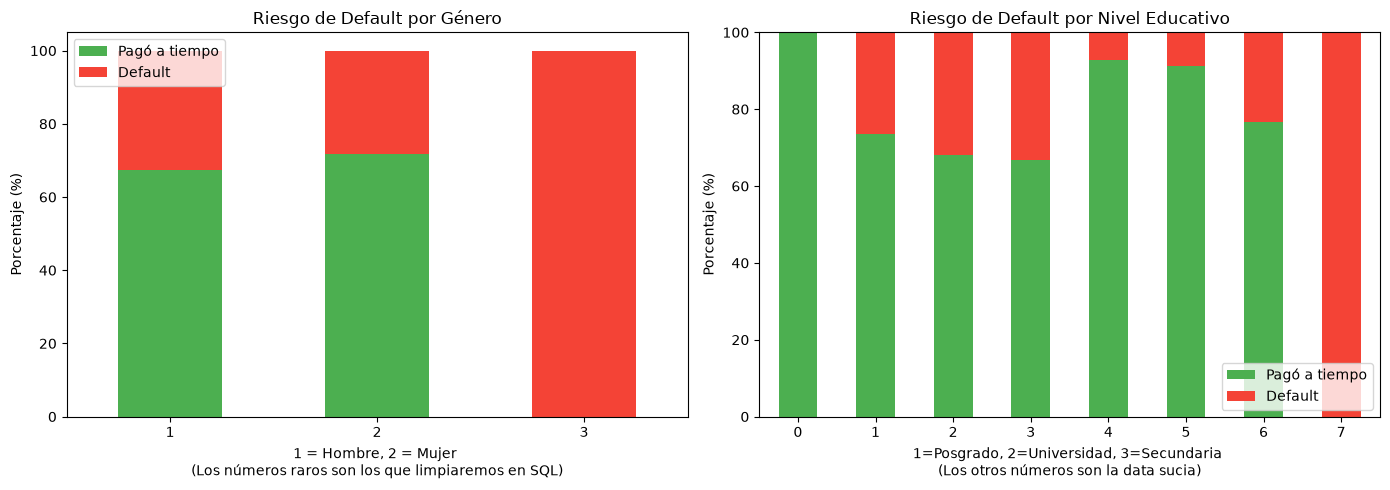

In [4]:
# Crear lienzo para 2 gráficos demográficos
plt.figure(figsize=(14, 5))

# Gráfico 3: Riesgo por Género
plt.subplot(1, 2, 1)
# Cruzamos la variable Sexo con la variable Default para sacar porcentajes
sexo_default = pd.crosstab(df['SEX'], df['default payment next month'], normalize='index') * 100
sexo_default.plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'], ax=plt.gca())
plt.title('Riesgo de Default por Género')
plt.xlabel('1 = Hombre, 2 = Mujer \n(Los números raros son los que limpiaremos en SQL)')
plt.ylabel('Porcentaje (%)')
plt.legend(['Pagó a tiempo', 'Default'], loc='upper left')
plt.xticks(rotation=0)

# Gráfico 4: Riesgo por Educación
plt.subplot(1, 2, 2)
# Cruzamos Educación con Default
edu_default = pd.crosstab(df['EDUCATION'], df['default payment next month'], normalize='index') * 100
edu_default.plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'], ax=plt.gca())
plt.title('Riesgo de Default por Nivel Educativo')
plt.xlabel('1=Posgrado, 2=Universidad, 3=Secundaria \n(Los otros números son la data sucia)')
plt.ylabel('Porcentaje (%)')
plt.legend(['Pagó a tiempo', 'Default'], loc='lower right')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


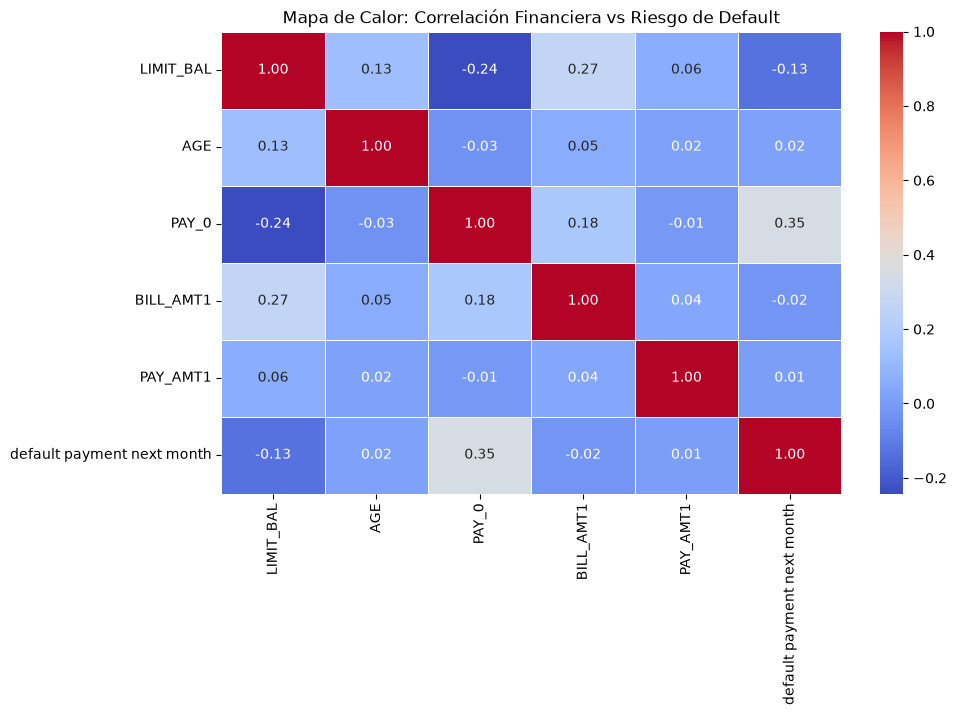

In [6]:
# Instalamos la librería visual 'seaborn' directamente desde aquí por si no la tienes
!pip install seaborn -q

import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos variables críticas para no saturar la pantalla
columnas_clave = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'default payment next month']
matriz_correlacion = df[columnas_clave].corr()

# Crear el lienzo y generar el mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación Financiera vs Riesgo de Default')
plt.show()